# 🌍 India City Air Quality Index Analysis (2015-2023)

**Dataset**: India City AQI Dataset 2015-2023
**Goal**: Analyze air pollution trends and predict AQI using ML

## 📊 Dataset Features
- **Pollutants**: PM2.5, PM10, NO2, SO2, CO, O3
- **Location**: Multiple Indian cities
- **Timeline**: 2015-2023 (8+ years)
- **Target**: AQI (Air Quality Index) and AQI Category


---
## 📦 Phase 1: Import Libraries


In [4]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# ML Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ML Utils
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
print("✅ Libraries imported!")


✅ Libraries imported!


---
## 📂 Phase 2: Load Dataset


In [21]:

df=pd.read_csv(r"india_city_aqi_2015_2023.csv")

---
## 🔍 Phase 3: Initial Exploration


In [22]:
print("=" * 80)
print("📊 DATASET OVERVIEW")
print("=" * 80 + "\n")

print("First 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\n📈 Statistical Summary:")
display(df.describe().T)


📊 DATASET OVERVIEW

First 5 rows:


,city,date,pm25,pm10,no2,so2,co,o3,aqi,aqi_category
0,Delhi,2015-01-01,99.868566,147.103280,49.715328,19.615149,0.729754,46.487946,103,Moderate
1,Delhi,2015-01-02,143.168513,208.517207,32.957884,14.712800,0.660975,43.014054,141,Moderate
2,Delhi,2015-01-03,89.678491,101.412886,14.126233,9.188562,0.496151,54.713710,82,Satisfactory
3,Delhi,2015-01-04,43.679037,65.432963,61.984732,10.871118,0.820258,28.628777,50,Good
4,Delhi,2015-01-05,58.224691,110.443143,22.735096,13.878490,0.619808,45.624594,69,Satisfactory



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32870 entries, 0 to 32869
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          32870 non-null  object 
 1   date          32870 non-null  object 
 2   pm25          32870 non-null  float64
 3   pm10          32870 non-null  float64
 4   no2           32870 non-null  float64
 5   so2           32870 non-null  float64
 6   co            32870 non-null  float64
 7   o3            32870 non-null  float64
 8   aqi           32870 non-null  int64  
 9   aqi_category  32870 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 2.5+ MB

📈 Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
pm25,32870.0,80.757235,39.063392,5.0,53.154180,80.336105,107.496909,248.081036
pm10,32870.0,130.764579,43.937066,10.0,99.980177,130.023453,160.634804,330.014171
no2,32870.0,40.165472,14.849411,5.0,29.990183,40.141525,50.190860,97.446733
so2,32870.0,11.998476,4.882239,2.0,8.570939,11.977979,15.315028,34.395421
co,32870.0,0.802118,0.298156,0.1,0.599976,0.800137,1.003899,1.929870
o3,32870.0,49.979732,14.912687,10.0,39.892800,49.977582,60.025440,118.431721
aqi,32870.0,88.122665,31.895407,11.0,65.000000,88.000000,110.000000,221.000000


---
## 🧹 Phase 4: Data Cleaning


In [23]:
print("=" * 80)
print("🔍 DATA QUALITY CHECK")
print("=" * 80 + "\n")

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)

if len(missing_df) > 0:
    print("⚠️ Missing Values:")
    display(missing_df)
else:
    print("✅ No missing values!")

# Duplicates
dups = df.duplicated().sum()
print(f"\n{'⚠️' if dups > 0 else '✅'} Duplicates: {dups}")

df_clean = df.copy()

# Parse dates
if 'date' in df_clean.columns:
    df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')
    print("\n✅ Date column parsed")

# Fill missing numeric values
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

print(f"\n✅ Clean dataset: {df_clean.shape}")


🔍 DATA QUALITY CHECK

✅ No missing values!

✅ Duplicates: 0

✅ Date column parsed

✅ Clean dataset: (32870, 10)


---
## 📊 Phase 5: Exploratory Data Analysis


📊 EXPLORATORY DATA ANALYSIS

🏙️ Cities in dataset:
city
Delhi        3287
Mumbai       3287
Bengaluru    3287
Kolkata      3287
Chennai      3287
Hyderabad    3287
Lucknow      3287
Jaipur       3287
Pune         3287
Ahmedabad    3287
Name: count, dtype: int64


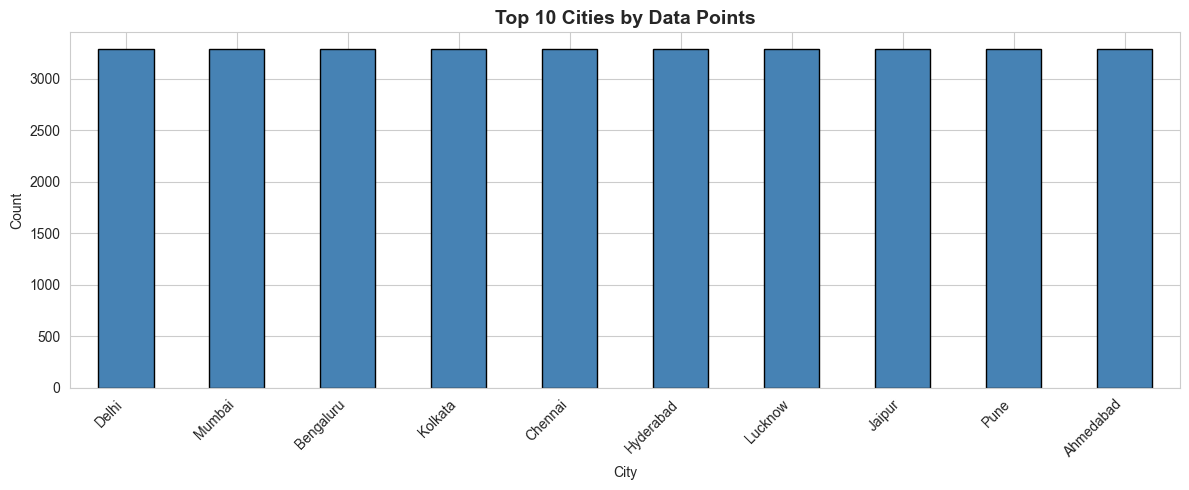


🎨 AQI Category Distribution:
aqi_category
Satisfactory    17244
Moderate        11433
Good             4183
Poor               10
Name: count, dtype: int64


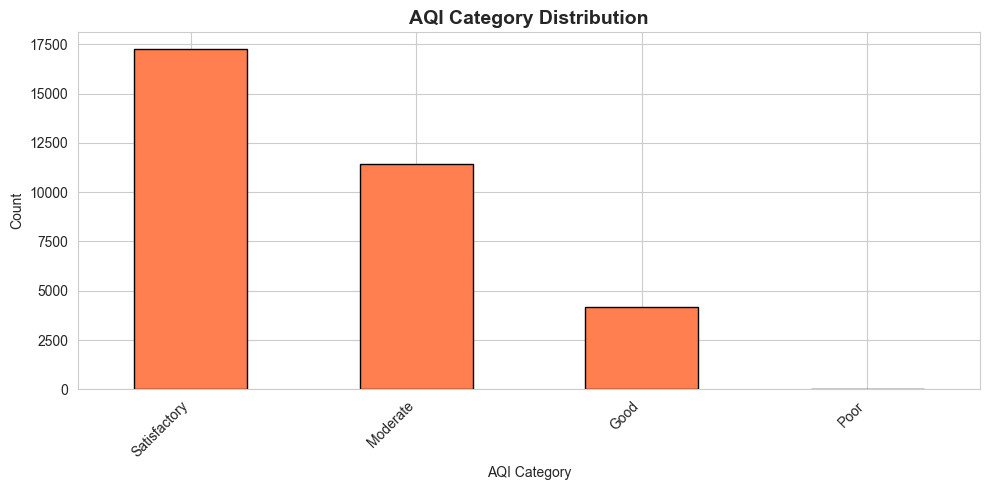

In [24]:
print("=" * 80)
print("📊 EXPLORATORY DATA ANALYSIS")
print("=" * 80 + "\n")

# City distribution
if 'city' in df_clean.columns:
    print("🏙️ Cities in dataset:")
    print(df_clean['city'].value_counts())
    
    plt.figure(figsize=(12, 5))
    df_clean['city'].value_counts().head(10).plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('Top 10 Cities by Data Points', fontsize=14, fontweight='bold')
    plt.xlabel('City')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# AQI Category distribution
if 'aqi_category' in df_clean.columns:
    print("\n🎨 AQI Category Distribution:")
    print(df_clean['aqi_category'].value_counts())
    
    plt.figure(figsize=(10, 5))
    df_clean['aqi_category'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
    plt.title('AQI Category Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('AQI Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


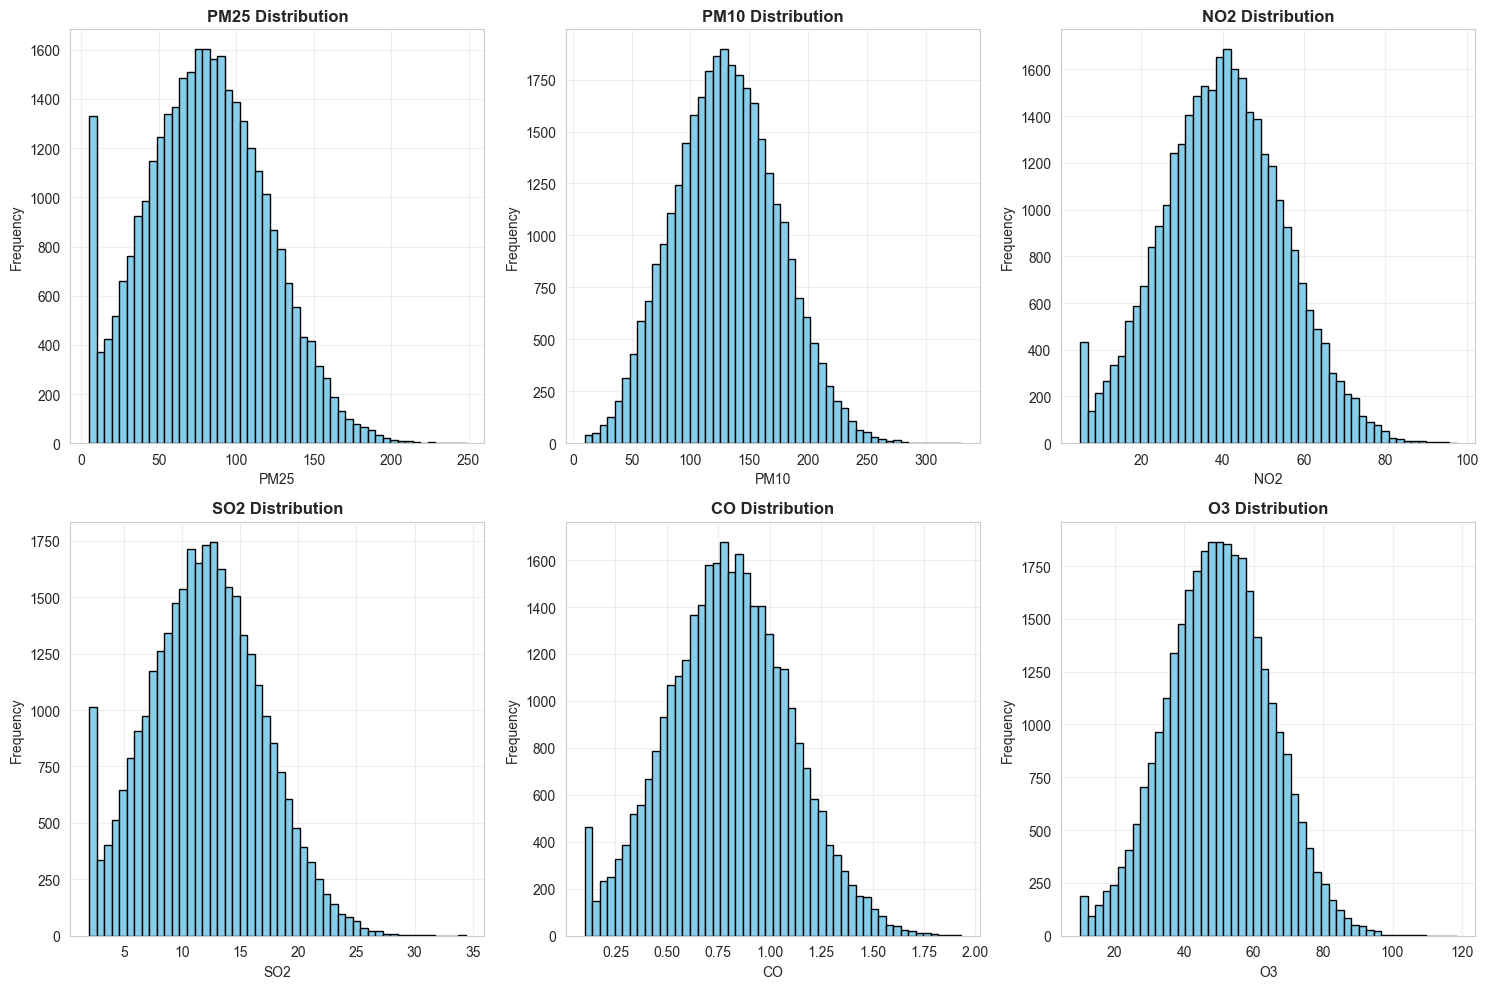

In [25]:
# Pollutant distributions
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
available_pollutants = [p for p in pollutants if p in df_clean.columns]

if available_pollutants:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, pol in enumerate(available_pollutants):
        axes[idx].hist(df_clean[pol], bins=50, color='skyblue', edgecolor='black')
        axes[idx].set_title(f'{pol.upper()} Distribution', fontweight='bold')
        axes[idx].set_xlabel(pol.upper())
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


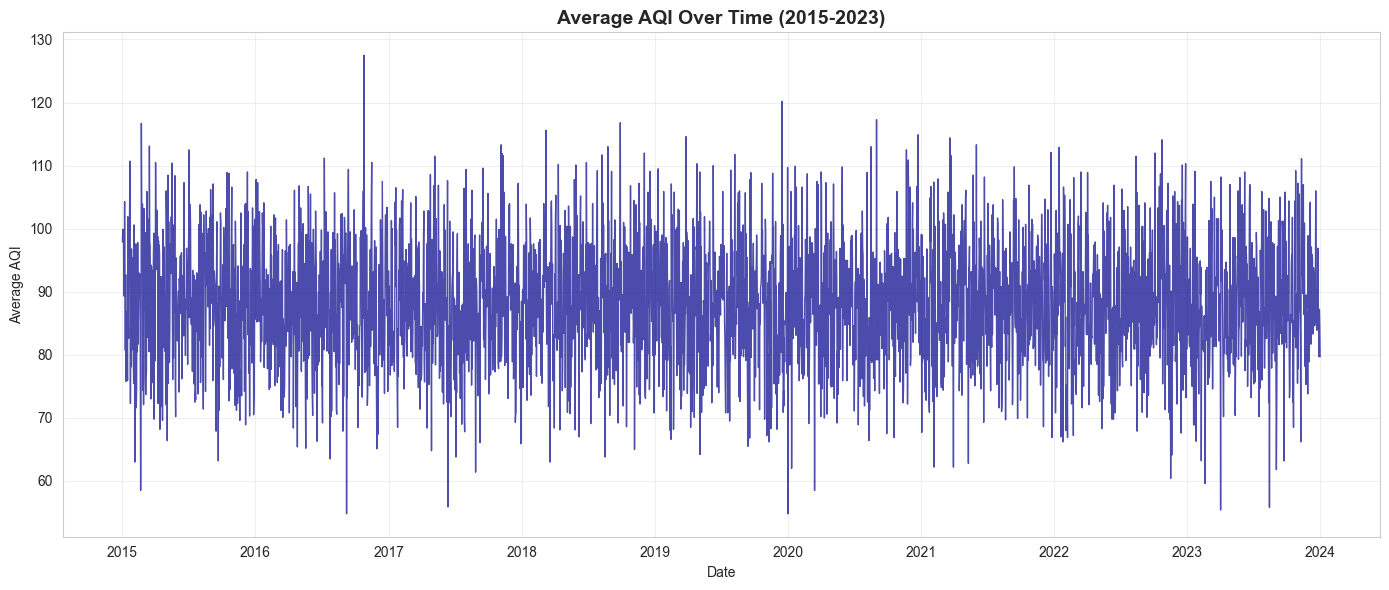

In [26]:
# AQI over time
if 'date' in df_clean.columns and 'aqi' in df_clean.columns:
    df_time = df_clean.groupby('date')['aqi'].mean().reset_index()
    
    plt.figure(figsize=(14, 6))
    plt.plot(df_time['date'], df_time['aqi'], linewidth=1, alpha=0.7, color='darkblue')
    plt.title('Average AQI Over Time (2015-2023)', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Average AQI')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


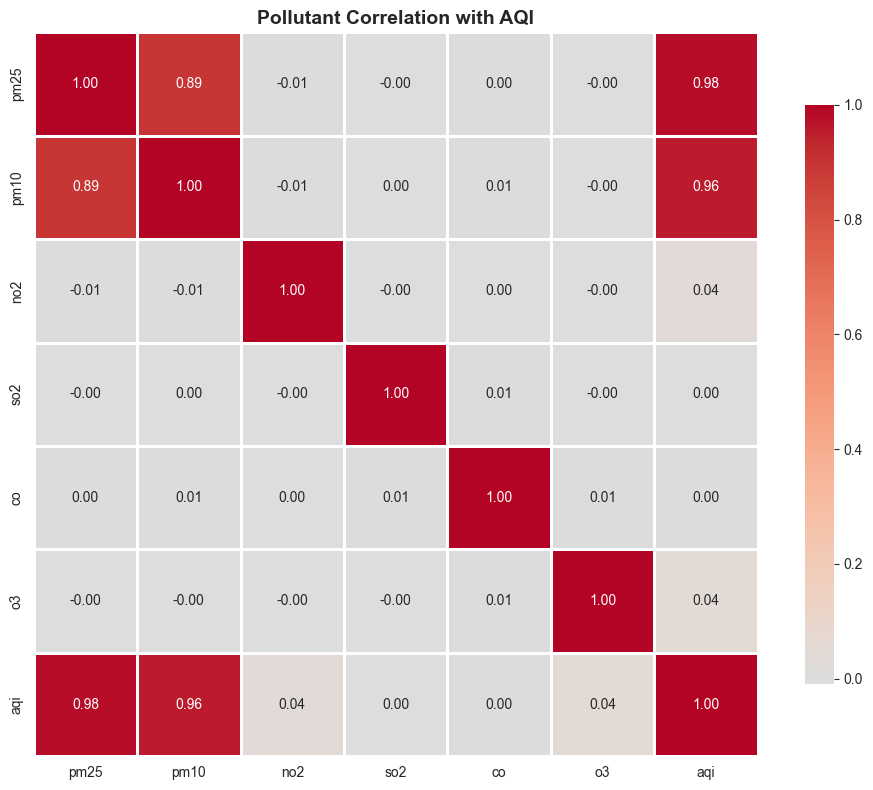

In [27]:
# Correlation heatmap
if 'aqi' in df_clean.columns:
    corr_cols = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'aqi']
    corr_cols = [c for c in corr_cols if c in df_clean.columns]
    
    if len(corr_cols) > 1:
        plt.figure(figsize=(10, 8))
        corr = df_clean[corr_cols].corr()
        sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
                    linewidths=1, square=True, cbar_kws={'shrink': 0.8})
        plt.title('Pollutant Correlation with AQI', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()


---
## ⚙️ Phase 6: Feature Engineering


In [28]:
print("=" * 80)
print("⚙️ FEATURE ENGINEERING")
print("=" * 80 + "\n")

df_features = df_clean.copy()
feat_count = 0

# Time features
if 'date' in df_features.columns:
    df_features['year'] = df_features['date'].dt.year
    df_features['month'] = df_features['date'].dt.month
    df_features['day'] = df_features['date'].dt.day
    df_features['dayofweek'] = df_features['date'].dt.dayofweek
    df_features['quarter'] = df_features['date'].dt.quarter
    df_features['is_weekend'] = (df_features['dayofweek'] >= 5).astype(int)
    feat_count += 6

# Pollutant ratios
if 'pm25' in df_features.columns and 'pm10' in df_features.columns:
    df_features['pm25_pm10_ratio'] = df_features['pm25'] / (df_features['pm10'] + 1)
    feat_count += 1

if 'no2' in df_features.columns and 'so2' in df_features.columns:
    df_features['no2_so2_ratio'] = df_features['no2'] / (df_features['so2'] + 1)
    feat_count += 1

# Total particulate matter
if 'pm25' in df_features.columns and 'pm10' in df_features.columns:
    df_features['total_pm'] = df_features['pm25'] + df_features['pm10']
    feat_count += 1

# Pollution severity score
pollutant_cols = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
available = [c for c in pollutant_cols if c in df_features.columns]
if available:
    df_features['pollution_score'] = df_features[available].mean(axis=1)
    feat_count += 1

# Rolling averages (7-day)
if 'aqi' in df_features.columns and 'date' in df_features.columns:
    df_features = df_features.sort_values('date')
    df_features['aqi_7day_avg'] = df_features['aqi'].rolling(window=7, min_periods=1).mean()
    df_features['aqi_7day_std'] = df_features['aqi'].rolling(window=7, min_periods=1).std().fillna(0)
    feat_count += 2

print(f"✅ Created {feat_count} new features")
print(f"📊 Total features: {df_features.shape[1]}\n")


⚙️ FEATURE ENGINEERING

✅ Created 12 new features
📊 Total features: 22



---
## 🎯 Phase 7: Prepare for Modeling


In [ ]:
print("=" * 80)
print("🎯 DATA PREPARATION")
print("=" * 80 + "\n")

# Encode categorical
le_city = None
if 'city' in df_features.columns:
    le_city = LabelEncoder()
    df_features['city_encoded'] = le_city.fit_transform(df_features['city'])
    print(f"✅ Encoded {df_features['city'].nunique()} cities")

# Select features for modeling
feature_cols = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 
                'year', 'month', 'day', 'dayofweek', 'quarter', 'is_weekend',
                'city_encoded', 'pm25_pm10_ratio', 'no2_so2_ratio', 
                'total_pm', 'pollution_score', 'aqi_7day_avg', 'aqi_7day_std']

feature_cols = [c for c in feature_cols if c in df_features.columns]

if 'aqi' in df_features.columns:
    X = df_features[feature_cols]
    y = df_features['aqi']
    
    # Remove NaN/inf
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())
    
    print(f"✅ Features: {X.shape[1]}")
    print(f"✅ Samples: {X.shape[0]:,}")
else:
    print("⚠️ AQI column not found")
    X = None
    y = None

🎯 DATA PREPARATION

✅ Encoded 10 cities
✅ Features: 19
✅ Samples: 32,870


---
## 📊 Phase 8: Train-Test Split


In [30]:
if X is not None and y is not None:
    # Time-based split (80-20)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    print("📊 Time-based Split (chronological):")
    print(f"   Train: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
    print(f"   Test: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
    
    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("\n✅ Features scaled!")


📊 Time-based Split (chronological):
   Train: 26,296 samples (80.0%)
   Test: 6,574 samples (20.0%)

✅ Features scaled!


---
## 🤖 Phase 9: Model Training


In [31]:
if X is not None:
    print("=" * 80)
    print("🤖 TRAINING ML MODELS")
    print("=" * 80 + "\n")
    
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0),
        'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42),
        'XGBoost': XGBRegressor(random_state=42),
        'LightGBM': LGBMRegressor(random_state=42, verbose=-1)
    }
    
    results = {}
    
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train_scaled, y_train)
        
        y_pred = model.predict(X_test_scaled)
        
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        
        results[name] = {'model': model, 'r2': r2, 'rmse': rmse, 'mae': mae, 'predictions': y_pred}
        
        print(f"   R²: {r2:.4f} | RMSE: {rmse:.2f} | MAE: {mae:.2f}\n")
    
    print("✅ All models trained!\n")


🤖 TRAINING ML MODELS

Training Linear Regression...
   R²: 0.9999 | RMSE: 0.29 | MAE: 0.25

Training Ridge Regression...
   R²: 0.9999 | RMSE: 0.29 | MAE: 0.25

Training Decision Tree...
   R²: 0.9985 | RMSE: 1.25 | MAE: 0.98

Training Random Forest...
   R²: 0.9996 | RMSE: 0.62 | MAE: 0.46

Training Gradient Boosting...
   R²: 0.9995 | RMSE: 0.70 | MAE: 0.54

Training XGBoost...
   R²: 0.9995 | RMSE: 0.75 | MAE: 0.51

Training LightGBM...
   R²: 0.9996 | RMSE: 0.65 | MAE: 0.43

✅ All models trained!



---
## 📈 Phase 10: Model Comparison


📈 MODEL COMPARISON



,Model,R²,RMSE,MAE
0,Linear Regression,0.999919,0.289441,0.251010
1,Ridge Regression,0.999919,0.289447,0.251007
3,Random Forest,0.999626,0.620915,0.462327
6,LightGBM,0.999594,0.646617,0.433145
4,Gradient Boosting,0.999530,0.696284,0.543474
5,XGBoost,0.999451,0.752523,0.510937
2,Decision Tree,0.998479,1.252309,0.983362


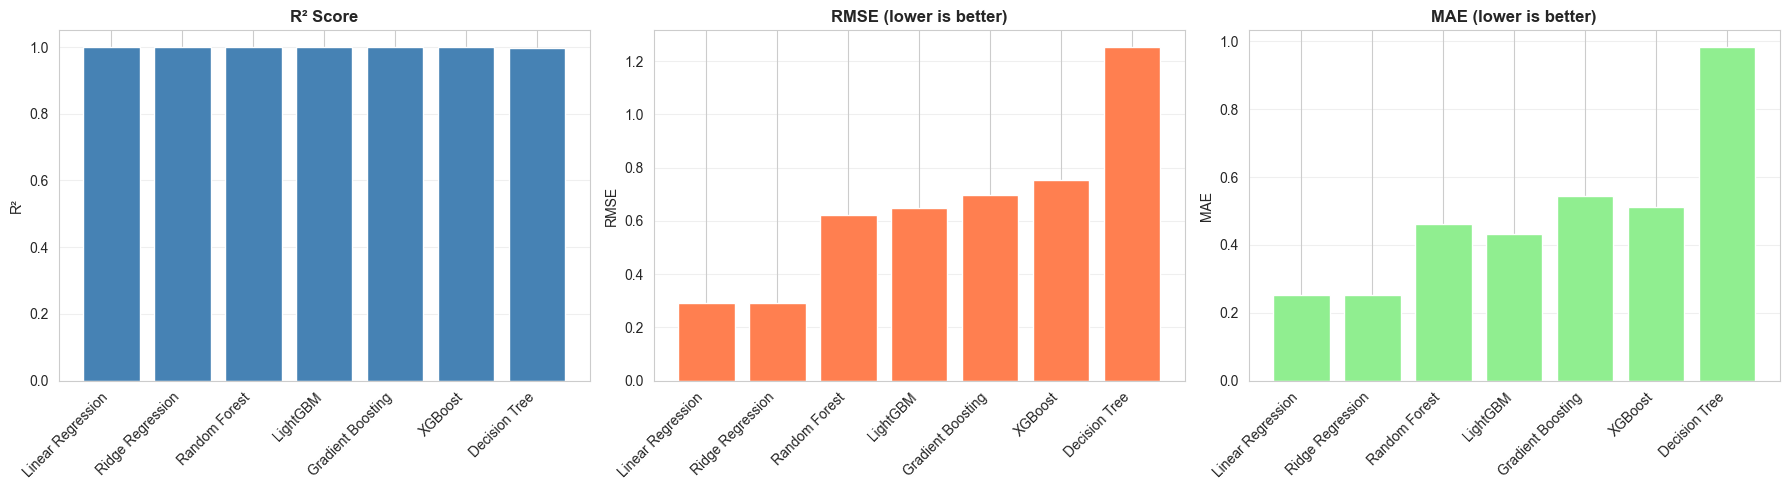


🏆 Best Model: Linear Regression (R² = 0.9999)


In [ ]:
import joblib
if X is not None:
    print("=" * 80)
    print("📈 MODEL COMPARISON")
    print("=" * 80 + "\n")
    
    comparison = pd.DataFrame({
        'Model': list(results.keys()),
        'R²': [results[m]['r2'] for m in results],
        'RMSE': [results[m]['rmse'] for m in results],
        'MAE': [results[m]['mae'] for m in results]
    }).sort_values('R²', ascending=False)
    
    display(comparison)
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].bar(comparison['Model'], comparison['R²'], color='steelblue')
    axes[0].set_title('R² Score', fontweight='bold')
    axes[0].set_xticklabels(comparison['Model'], rotation=45, ha='right')
    axes[0].set_ylabel('R²')
    axes[0].grid(alpha=0.3, axis='y')
    
    axes[1].bar(comparison['Model'], comparison['RMSE'], color='coral')
    axes[1].set_title('RMSE (lower is better)', fontweight='bold')
    axes[1].set_xticklabels(comparison['Model'], rotation=45, ha='right')
    axes[1].set_ylabel('RMSE')
    axes[1].grid(alpha=0.3, axis='y')
    
    axes[2].bar(comparison['Model'], comparison['MAE'], color='lightgreen')
    axes[2].set_title('MAE (lower is better)', fontweight='bold')
    axes[2].set_xticklabels(comparison['Model'], rotation=45, ha='right')
    axes[2].set_ylabel('MAE')
    axes[2].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    best_model_name = comparison.iloc[0]['Model']
    best_r2 = comparison.iloc[0]['R²']
    print(f"\n🏆 Best Model: {best_model_name} (R² = {best_r2:.4f})")
    


---
## 🎯 Phase 11: Best Model Analysis


🎯 BEST MODEL: Linear Regression



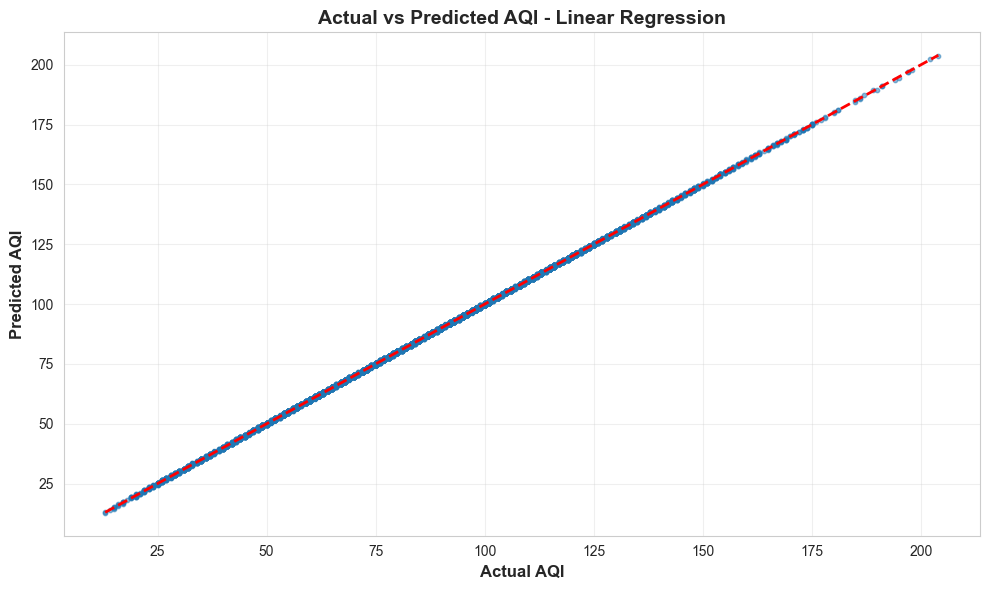

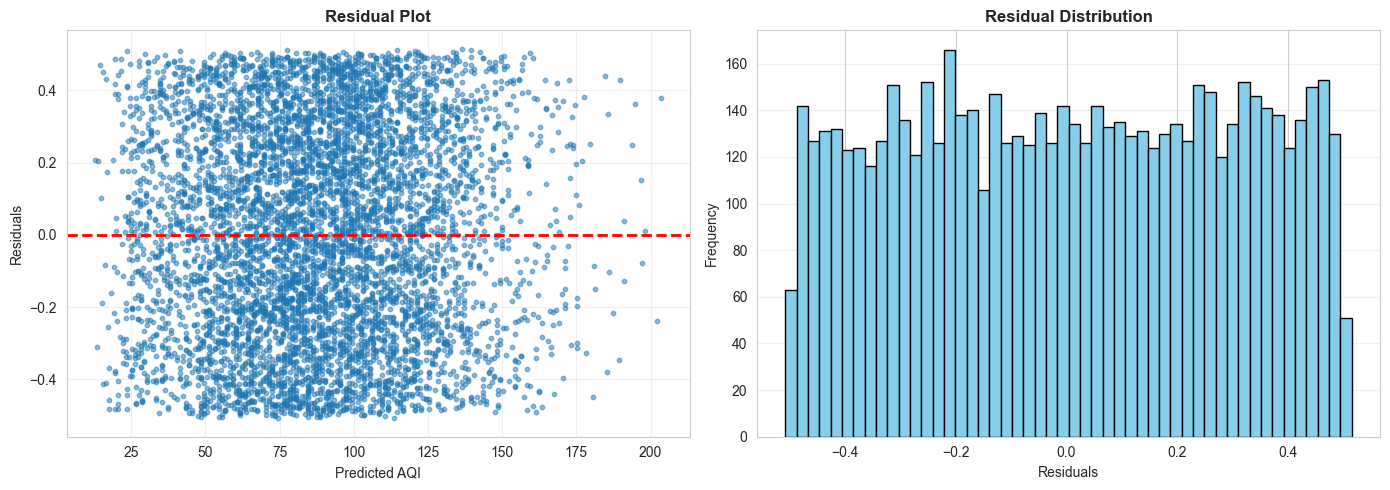

In [33]:
if X is not None:
    print("=" * 80)
    print(f"🎯 BEST MODEL: {best_model_name}")
    print("=" * 80 + "\n")
    
    best_model = results[best_model_name]['model']
    best_pred = results[best_model_name]['predictions']
    
    # Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, best_pred, alpha=0.5, s=10)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual AQI', fontsize=12, fontweight='bold')
    plt.ylabel('Predicted AQI', fontsize=12, fontweight='bold')
    plt.title(f'Actual vs Predicted AQI - {best_model_name}', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Residuals
    residuals = y_test - best_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].scatter(best_pred, residuals, alpha=0.5, s=10)
    axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[0].set_xlabel('Predicted AQI')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residual Plot', fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    axes[1].hist(residuals, bins=50, edgecolor='black', color='skyblue')
    axes[1].set_xlabel('Residuals')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Residual Distribution', fontweight='bold')
    axes[1].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()


---
## 🔍 Phase 12: Feature Importance


In [34]:
if X is not None and hasattr(best_model, 'feature_importances_'):
    print("=" * 80)
    print("🔍 FEATURE IMPORTANCE")
    print("=" * 80 + "\n")
    
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("Top 10 Features:")
    display(importance_df.head(10))
    
    plt.figure(figsize=(10, 6))
    top10 = importance_df.head(10)
    plt.barh(top10['Feature'], top10['Importance'], color='steelblue')
    plt.xlabel('Importance', fontsize=12, fontweight='bold')
    plt.title('Top 10 Feature Importances', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()


---
## 🎓 Phase 13: Key Insights


In [35]:
if X is not None:
    print("=" * 80)
    print("🎓 KEY INSIGHTS")
    print("=" * 80 + "\n")
    
    print(f"📊 Dataset:")
    print(f"   Total samples: {len(df):,}")
    print(f"   Date range: {df_clean['date'].min()} to {df_clean['date'].max()}")
    print(f"   Cities: {df_clean['city'].nunique() if 'city' in df_clean.columns else 'N/A'}\n")
    
    print(f"🏆 Best Model: {best_model_name}")
    print(f"   R² Score: {results[best_model_name]['r2']:.4f}")
    print(f"   RMSE: {results[best_model_name]['rmse']:.2f}")
    print(f"   MAE: {results[best_model_name]['mae']:.2f}\n")
    
    if 'aqi' in df_clean.columns:
        print(f"📈 AQI Statistics:")
        print(f"   Mean: {df_clean['aqi'].mean():.1f}")
        print(f"   Median: {df_clean['aqi'].median():.1f}")
        print(f"   Min: {df_clean['aqi'].min():.1f}")
        print(f"   Max: {df_clean['aqi'].max():.1f}")
    
    print("\n✅ Analysis Complete!")


🎓 KEY INSIGHTS

📊 Dataset:
   Total samples: 32,870
   Date range: 2015-01-01 00:00:00 to 2023-12-31 00:00:00
   Cities: 10

🏆 Best Model: Linear Regression
   R² Score: 0.9999
   RMSE: 0.29
   MAE: 0.25

📈 AQI Statistics:
   Mean: 88.1
   Median: 88.0
   Min: 11.0
   Max: 221.0

✅ Analysis Complete!


In [36]:
import joblib

In [37]:
joblib.dump(model,"model.joblib")

['model.joblib']